In [1]:
# Import libraries
import pandas as pd
import numpy as np
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

In [2]:
# Load dataset
data = pd.read_csv(r"C:\Users\tanay\Downloads\letter-recognition.data", header=None)

In [3]:
# Features and labels
X = data.iloc[:, 1:].values
y = data.iloc[:, 0].values

In [4]:
# Convert letters A-Z into numbers 0-25
encoder = LabelEncoder()
y = encoder.fit_transform(y)

In [5]:
# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [7]:
# Build DNN model
model = keras.Sequential([
    keras.Input(shape=(X_train.shape[1],)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(26, activation='softmax')   # 26 classes
])

In [8]:
# Compile model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [9]:
# Train model
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)


Epoch 1/50
450/450 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.6018 - loss: 1.4758 - val_accuracy: 0.7356 - val_loss: 0.8543
Epoch 2/50
450/450 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.7935 - loss: 0.7048 - val_accuracy: 0.8131 - val_loss: 0.6228
Epoch 3/50
450/450 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8425 - loss: 0.5289 - val_accuracy: 0.8575 - val_loss: 0.4764
Epoch 4/50
450/450 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.8746 - loss: 0.4256 - val_accuracy: 0.8794 - val_loss: 0.3972
Epoch 5/50
450/450 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8949 - loss: 0.3566 - val_accuracy: 0.9075 - val_loss: 0.3341
Epoch 6/50
450/450 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9083 - loss: 0.3043 - val_accuracy: 0.9106 - val_loss: 0.2934
Epoch 7/50
450/450 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9185 - loss: 0.2687 - val_accuracy: 0.9162 - val_loss: 0.2797
Epoch 8/50
450/450 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.9249 - loss: 0.2377 - val_accuracy: 

In [10]:
# Evaluate model
loss, accuracy = model.evaluate(X_test, y_test)

125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9565 - loss: 0.1471


In [11]:
print("Accuracy:", accuracy)

Accuracy: 0.9564999938011169


In [12]:
# Predictions
predictions = model.predict(X_test)

125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


In [13]:
# Convert probabilities to class labels
predicted_classes = np.argmax(predictions, axis=1)

In [14]:
# Display sample predictions
for i in range(10):
    actual = encoder.inverse_transform([y_test[i]])[0]
    predicted = encoder.inverse_transform([predicted_classes[i]])[0]

    print(f"Actual: {actual} | Predicted: {predicted}")


Actual: T | Predicted: X
Actual: L | Predicted: L
Actual: A | Predicted: A
Actual: E | Predicted: E
Actual: Q | Predicted: Q
Actual: E | Predicted: E
Actual: O | Predicted: O
Actual: Q | Predicted: Q
Actual: G | Predicted: G
Actual: O | Predicted: O


In [15]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │           2,176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 26)                  │           1,690 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 36,368 (142.07 KB)

 Trainable params: 12,122 (47.35 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 24,246 (94.71 KB)

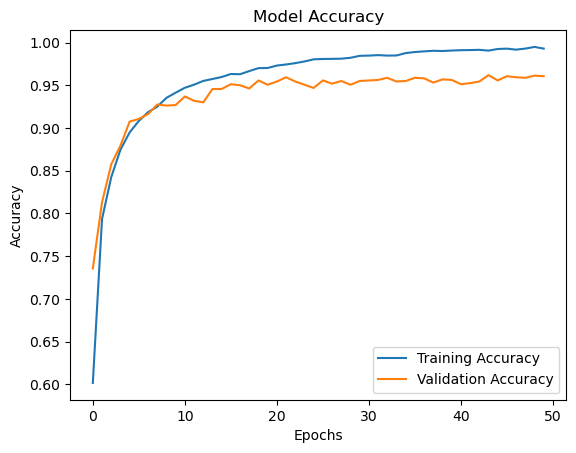

In [16]:
# Plot accuracy graph
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')
plt.legend()

plt.show()